### Transfer Learning with DenseNet121 and MobileNetV2

In [1]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import os
import zipfile
import shutil
from google.colab import drive

# Mount Google Drive and extract dataset
print("[INFO] Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

zip_path_on_drive = '/content/drive/My Drive/Project/AI TOOLS/data.zip'
extract_path = 'data'
temp_extract = "temp_extracted"

if not os.path.exists(zip_path_on_drive):
    raise FileNotFoundError(f"[ERROR] Could not find 'data.zip' at: {zip_path_on_drive}")

print(f"[INFO] Extracting dataset from: {zip_path_on_drive}...")
if os.path.exists(temp_extract):
    shutil.rmtree(temp_extract)
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path_on_drive, 'r') as zip_ref:
    zip_ref.extractall(temp_extract)

# Handle nested folder structure if any
actual_data_dir = temp_extract
subdirs = os.listdir(temp_extract)
if len(subdirs) == 1 and os.path.isdir(os.path.join(temp_extract, subdirs[0])):
    potential_nested = os.path.join(temp_extract, subdirs[0])
    inner_subdirs = os.listdir(potential_nested)
    if any(cls in [d.lower() for d in inner_subdirs] for cls in ['resistor', 'capacitor', 'diode']):
        actual_data_dir = potential_nested

shutil.copytree(actual_data_dir, extract_path)
shutil.rmtree(temp_extract)
print("[SUCCESS] Dataset extracted and structured successfully!")

[INFO] Mounting Google Drive...
Mounted at /content/drive
[INFO] Extracting dataset from: /content/drive/My Drive/Project/AI TOOLS/data.zip...
[SUCCESS] Dataset extracted and structured successfully!


Cell 2: Prepare DataLoaders

In [2]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

data_dir = 'data'
batch_size =6

# Define the three-way split ratios (e.g., 70% train, 15% validation, 15% test)
train_split = 0.70
val_split = 0.15
test_split = 0.15  # Remaining will be handled automatically

# IMPORTANT: augmentation (flip/rotation) must ONLY be applied to the
# training set. Validation and test data should reflect real-world,
# un-augmented inputs so the reported metrics measure true generalization.
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if not os.path.exists(data_dir):
    raise NotADirectoryError(f"[ERROR] Directory '{data_dir}' not found. Please run Cell 1 first.")

# Two ImageFolder views over the SAME files (ImageFolder orders files
# deterministically), one with train-time augmentation and one without.
# We then split indices once and hand matching indices to each view via
# Subset, so train/val/test contain the same images as before, but only
# the training subset gets augmented.
base_dataset = datasets.ImageFolder(data_dir, transform=eval_transforms)
train_view = datasets.ImageFolder(data_dir, transform=train_transforms)
class_names = base_dataset.classes
print(f"[INFO] Classes detected correctly: {class_names}")

total_size = len(base_dataset)
train_size = int(train_split * total_size)
val_size = int(val_split * total_size)
test_size = total_size - train_size - val_size  # Ensure no samples are lost due to rounding

# Use a fixed random seed generator to ensure reproducibility
generator = torch.Generator().manual_seed(42)
train_idx, val_idx, test_idx = random_split(
    range(total_size), [train_size, val_size, test_size], generator=generator
)

train_dataset = Subset(train_view, train_idx.indices)   # augmented
val_dataset = Subset(base_dataset, val_idx.indices)      # NOT augmented
test_dataset = Subset(base_dataset, test_idx.indices)    # NOT augmented

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"[SUCCESS] DataLoaders created successfully!")
print(f" - Training samples: {train_size} (augmented)")
print(f" - Validation samples: {val_size} (not augmented)")
print(f" - Test samples: {test_size} (not augmented)")

[INFO] Classes detected correctly: ['capacitor', 'diode', 'resistor']
[SUCCESS] DataLoaders created successfully!
 - Training samples: 518 (augmented)
 - Validation samples: 111 (not augmented)
 - Test samples: 112 (not augmented)


Training Function (with Early Stopping & L2 Regularization)

In [3]:
import copy
import torch
import torch.nn as nn

def freeze_batchnorm_layers(model):
    """Freezes every BatchNorm2d layer in `model`:
       - module.eval()            -> stops updating running_mean/running_var
       - requires_grad = False    -> stops updating gamma (weight) & beta (bias)
    Call this ONCE, right after you decide which blocks are unfrozen,
    so BatchNorm stays frozen even inside blocks you otherwise fine-tune."""
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()
            for param in module.parameters():
                param.requires_grad = False


def freeze_bn(model):
    """Re-applies .eval() to every BatchNorm layer whose params are frozen
    (requires_grad=False). This MUST be called after every model.train(),
    because model.train() flips ALL submodules (including BN layers we
    froze earlier) back into training mode, which would otherwise silently
    undo the freeze and let running_mean/running_var keep updating."""
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            frozen = all(not p.requires_grad for p in module.parameters(recurse=False))
            if frozen:
                module.eval()


def train_and_evaluate(model, train_loader, val_loader, train_size, val_size, optimizer, criterion, device, num_epochs=15, patience=4):
    """Trains the model with Early Stopping and L2 Regularization (weight_decay)."""

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    patience_counter = 0

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        freeze_bn(model)  # keep any frozen BatchNorm layers in eval mode
        train_loss = 0.0
        train_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_corrects += torch.sum(preds == labels.data)

        train_epoch_loss = train_loss / train_size
        train_epoch_acc = train_corrects.double().item() / train_size

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / val_size
        val_epoch_acc = val_corrects.double().item() / val_size

        # Save history
        train_losses.append(train_epoch_loss)
        val_losses.append(val_epoch_loss)
        train_accuracies.append(train_epoch_acc)
        val_accuracies.append(val_epoch_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] -> "
              f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.4f} || "
              f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

        # Check for best model & Early Stopping logic
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0  # Reset patience
            print(f"--> [CHECKPOINT] Best model updated with Val Acc: {val_epoch_acc:.4f}")
        else:
            patience_counter += 1
            print(f"--> [WARNING] No improvement. Early Stopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n[INFO] Early stopping triggered at epoch {epoch+1}!")
            break

    # Load best weights
    model.load_state_dict(best_model_wts)
    history = {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accuracies, 'val_acc': val_accuracies
    }
    return model, history

Cell 4: Run Model A (Feature Extraction) — DenseNet121

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Running Model A: DenseNet121 Feature Extraction")

model_a = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

# 1) Freeze the entire backbone (feature extractor)
for param in model_a.features.parameters():
    param.requires_grad = False

# 2) Freeze BatchNorm layers explicitly (eval mode + no grad on gamma/beta)
freeze_batchnorm_layers(model_a)

# 3) Replace classifier
num_features = model_a.classifier.in_features

model_a.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names))
)

model_a = model_a.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_a = optim.Adam(
    model_a.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_a,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

model_a, history_a = train_and_evaluate(
    model_a,
    train_loader,
    val_loader,
    train_size,
    val_size,
    optimizer_a,
    criterion,
    device,
    num_epochs=20,
    patience=6,
)

[INFO] Running Model A: DenseNet121 Feature Extraction
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 153MB/s]


Epoch [1/20] -> Train Loss: 0.7969 | Train Acc: 0.6429 || Val Loss: 0.4007 | Val Acc: 0.8739
--> [CHECKPOINT] Best model updated with Val Acc: 0.8739
Epoch [2/20] -> Train Loss: 0.4649 | Train Acc: 0.8069 || Val Loss: 0.2436 | Val Acc: 0.9279
--> [CHECKPOINT] Best model updated with Val Acc: 0.9279
Epoch [3/20] -> Train Loss: 0.4068 | Train Acc: 0.8301 || Val Loss: 0.2016 | Val Acc: 0.9279
--> [WARNING] No improvement. Early Stopping counter: 1/6
Epoch [4/20] -> Train Loss: 0.4463 | Train Acc: 0.8205 || Val Loss: 0.2199 | Val Acc: 0.9369
--> [CHECKPOINT] Best model updated with Val Acc: 0.9369
Epoch [5/20] -> Train Loss: 0.3231 | Train Acc: 0.8629 || Val Loss: 0.1797 | Val Acc: 0.9369
--> [WARNING] No improvement. Early Stopping counter: 1/6
Epoch [6/20] -> Train Loss: 0.4082 | Train Acc: 0.8417 || Val Loss: 0.2662 | Val Acc: 0.9189
--> [WARNING] No improvement. Early Stopping counter: 2/6
Epoch [7/20] -> Train Loss: 0.3786 | Train Acc: 0.8610 || Val Loss: 0.2112 | Val Acc: 0.9189
--> 

Cell 5: Model B (Fine-Tuning) — DenseNet121

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Running Model B: DenseNet121 Partial Fine-Tuning (Frozen BatchNorm) on {device}")

# --------------------------------------------------
# Load pretrained DenseNet121
# --------------------------------------------------
model_b = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

# --------------------------------------------------
# 1) Freeze entire backbone
# --------------------------------------------------
for param in model_b.parameters():
    param.requires_grad = False


# --------------------------------------------------
# 2) Unfreeze denseblock4 + norm5
# --------------------------------------------------
for name, module in model_b.features.named_children():
    if name in ["denseblock4", "norm5"]:
        for param in module.parameters():
            param.requires_grad = True

# --------------------------------------------------
# 3) Freeze ALL BatchNorm layers (even inside denseblock4/norm5 above)
# --------------------------------------------------
freeze_batchnorm_layers(model_b)

# --------------------------------------------------
# 4) Replace classifier
# --------------------------------------------------
num_features = model_b.classifier.in_features

model_b.classifier = nn.Linear(
    num_features,
    len(class_names)
)

# Train classifier
for param in model_b.classifier.parameters():
    param.requires_grad = True


model_b = model_b.to(device)


# --------------------------------------------------
# Check trainable layers
# --------------------------------------------------
trainable_params = []

for name, param in model_b.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)

print("\n[INFO] Trainable layers:")
for layer in trainable_params:
    print(layer)


# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer_b = optim.SGD(
    filter(lambda p: p.requires_grad, model_b.parameters()),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)


criterion = nn.CrossEntropyLoss()


# --------------------------------------------------
# Training
# --------------------------------------------------
model_b, history_b = train_and_evaluate(
    model_b,
    train_loader,
    val_loader,
    train_size,
    val_size,
    optimizer_b,
    criterion,
    device,
    num_epochs=15,
    patience=4
)

[INFO] Running Model B: DenseNet121 Partial Fine-Tuning (Frozen BatchNorm) on cuda

[INFO] Trainable layers:
features.denseblock4.denselayer1.conv1.weight
features.denseblock4.denselayer1.conv2.weight
features.denseblock4.denselayer2.conv1.weight
features.denseblock4.denselayer2.conv2.weight
features.denseblock4.denselayer3.conv1.weight
features.denseblock4.denselayer3.conv2.weight
features.denseblock4.denselayer4.conv1.weight
features.denseblock4.denselayer4.conv2.weight
features.denseblock4.denselayer5.conv1.weight
features.denseblock4.denselayer5.conv2.weight
features.denseblock4.denselayer6.conv1.weight
features.denseblock4.denselayer6.conv2.weight
features.denseblock4.denselayer7.conv1.weight
features.denseblock4.denselayer7.conv2.weight
features.denseblock4.denselayer8.conv1.weight
features.denseblock4.denselayer8.conv2.weight
features.denseblock4.denselayer9.conv1.weight
features.denseblock4.denselayer9.conv2.weight
features.denseblock4.denselayer10.conv1.weight
features.densebl

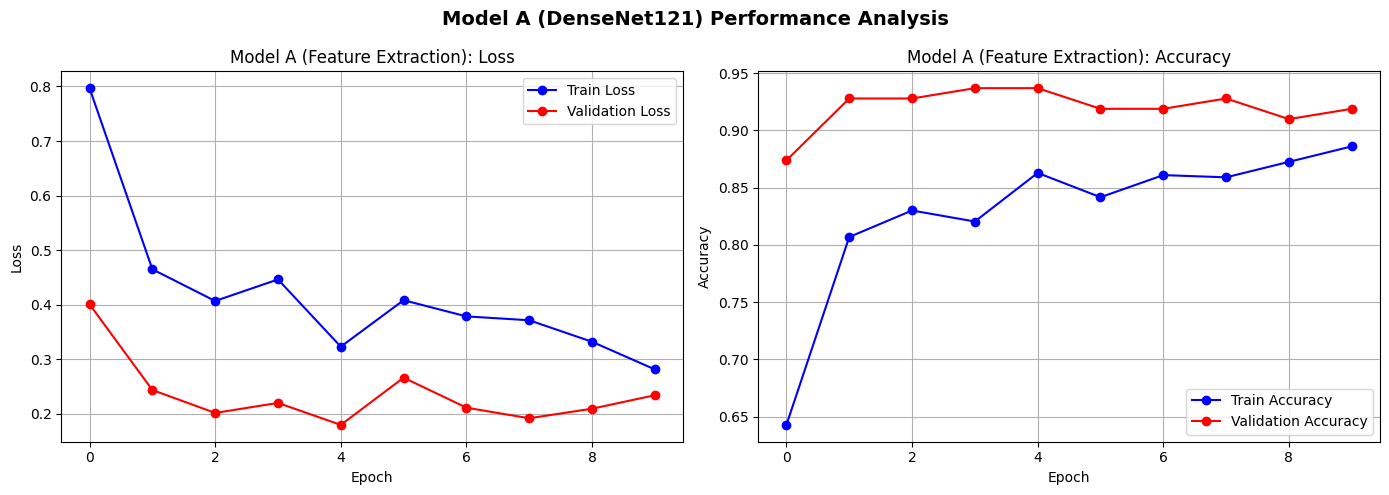

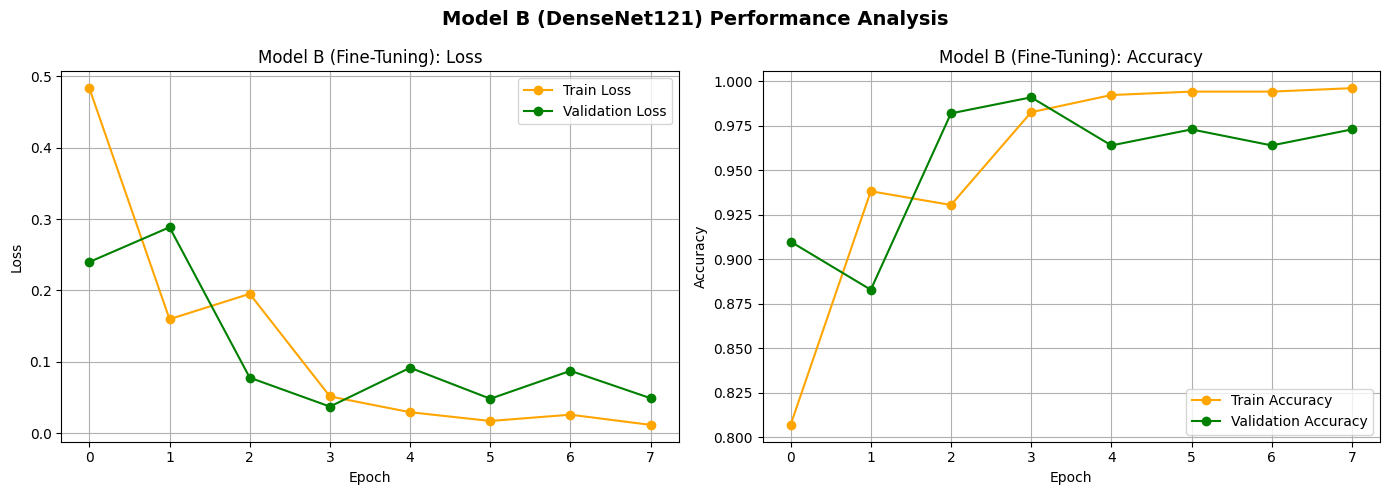


--- [MODEL SELECTION -- VALIDATION ACCURACY] ---
Model A (Feature Extraction) Best Val Accuracy: 0.9369
Model B (Fine-Tuning) Best Val Accuracy: 0.9910

[SELECTED] Model B selected for test-set evaluation (higher val accuracy).

--- [UNSEEN TEST SET EVALUATION] ---
Test Loss: 0.0767 | Test Accuracy: 0.9821

>>> FINAL REPORTED ACCURACY (use this number in the report): 98.21% <<<

--- [CLASSIFICATION REPORT] ---
              precision    recall  f1-score   support

   capacitor       1.00      1.00      1.00        48
       diode       0.94      1.00      0.97        29
    resistor       1.00      0.94      0.97        35

    accuracy                           0.98       112
   macro avg       0.98      0.98      0.98       112
weighted avg       0.98      0.98      0.98       112



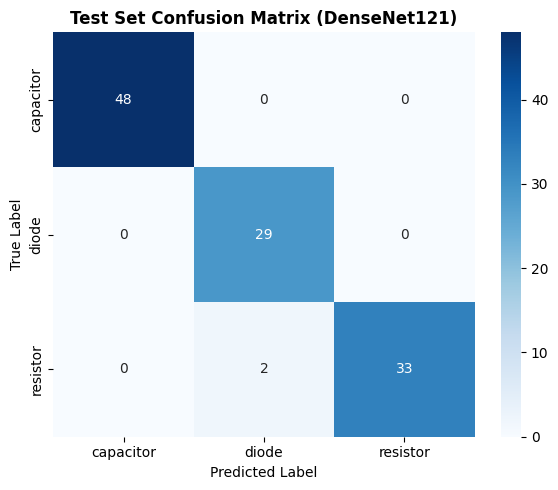

[SUCCESS] Best model weights saved as 'best_model_b_finetune_densenet.pth'.
[INFO] Downloading 'best_model_b_finetune_densenet.pth' to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
"""Cell 6: Direct Comparison & Plotting (Model A vs Model B) — DenseNet121"""

import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from google.colab import files

# --- Plot Model A: Train vs Validation ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_a['train_loss'], label='Train Loss', marker='o', color='blue')
plt.plot(history_a['val_loss'], label='Validation Loss', marker='o', color='red')
plt.title('Model A (Feature Extraction): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_a['train_acc'], label='Train Accuracy', marker='o', color='blue')
plt.plot(history_a['val_acc'], label='Validation Accuracy', marker='o', color='red')
plt.title('Model A (Feature Extraction): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model A (DenseNet121) Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot Model B: Train vs Validation ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_b['train_loss'], label='Train Loss', marker='o', color='orange')
plt.plot(history_b['val_loss'], label='Validation Loss', marker='o', color='green')
plt.title('Model B (Fine-Tuning): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_b['train_acc'], label='Train Accuracy', marker='o', color='orange')
plt.plot(history_b['val_acc'], label='Validation Accuracy', marker='o', color='green')
plt.title('Model B (Fine-Tuning): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model B (DenseNet121) Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Determine the best model based on Validation Accuracy ---
# NOTE: validation accuracy is used ONLY to select which model to carry
# forward to the held-out test set. It is NOT the final reported metric --
# the test accuracy computed below is the number that belongs in the report.
max_acc_a = max(history_a['val_acc'])
max_acc_b = max(history_b['val_acc'])

print(f"\n--- [MODEL SELECTION -- VALIDATION ACCURACY] ---")
print(f"Model A (Feature Extraction) Best Val Accuracy: {max_acc_a:.4f}")
print(f"Model B (Fine-Tuning) Best Val Accuracy: {max_acc_b:.4f}")

if max_acc_b >= max_acc_a:
    best_model = model_b
    best_file = "best_model_b_finetune_densenet.pth"
    print(f"\n[SELECTED] Model B selected for test-set evaluation (higher val accuracy).")
else:
    best_model = model_a
    best_file = "best_model_a_fe_densenet.pth"
    print(f"\n[SELECTED] Model A selected for test-set evaluation (higher val accuracy).")

# --- Final Rigorous Evaluation on the Unseen Test Set ---
print(f"\n--- [UNSEEN TEST SET EVALUATION] ---")
best_model.eval()
test_loss = 0.0
test_corrects = 0
all_preds = []
all_labels = []

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_epoch_loss = test_loss / test_size
test_epoch_acc = test_corrects.double().item() / test_size

print(f"Test Loss: {test_epoch_loss:.4f} | Test Accuracy: {test_epoch_acc:.4f}")
print(f"\n>>> FINAL REPORTED ACCURACY (use this number in the report): {test_epoch_acc*100:.2f}% <<<")

# --- Generate Confusion Matrix & Classification Report ---
print("\n--- [CLASSIFICATION REPORT] ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Test Set Confusion Matrix (DenseNet121)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Save and Download Best Model Weights ---
torch.save(best_model.state_dict(), best_file)
print(f"[SUCCESS] Best model weights saved as '{best_file}'.")
print(f"[INFO] Downloading '{best_file}' to your computer...")
files.download(best_file)

Cell 15 (Ablation A2) — DenseNet121

In [7]:
# --- Ablation A2: denseblock4 + norm5 + classifier unfrozen, Adam (DenseNet121) ---
model_a2 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
for param in model_a2.parameters():
    param.requires_grad = False

unfreeze_from_here = False
for name, module in model_a2.features.named_children():
    if name == 'denseblock4':
        unfreeze_from_here = True
    if unfreeze_from_here:
        for param in module.parameters():
            param.requires_grad = True

model_a2.classifier = nn.Linear(model_a2.classifier.in_features, len(class_names))
for param in model_a2.classifier.parameters():
    param.requires_grad = True
model_a2 = model_a2.to(device)

optimizer_a2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_a2.parameters()),
    lr=0.001, weight_decay=1e-4
)

model_a2, history_a2 = train_and_evaluate(
    model_a2, train_loader, val_loader, train_size, val_size,
    optimizer_a2, criterion, device, num_epochs=15, patience=4
)

print(f"\n[ABLATION] denseblock4+classifier unfrozen, Adam -- Best Val Acc: {max(history_a2['val_acc']):.4f}")
print(f"[ABLATION] denseblock4+classifier unfrozen, SGD   -- Best Val Acc: {max_acc_b:.4f}  (this is Model B, already trained above)")
print("\nCompare these two lines directly -- same unfrozen layers, optimizer is the only difference.")

Epoch [1/15] -> Train Loss: 0.4768 | Train Acc: 0.7992 || Val Loss: 0.2468 | Val Acc: 0.8919
--> [CHECKPOINT] Best model updated with Val Acc: 0.8919
Epoch [2/15] -> Train Loss: 0.2663 | Train Acc: 0.9093 || Val Loss: 0.1294 | Val Acc: 0.9550
--> [CHECKPOINT] Best model updated with Val Acc: 0.9550
Epoch [3/15] -> Train Loss: 0.2599 | Train Acc: 0.9015 || Val Loss: 0.0206 | Val Acc: 1.0000
--> [CHECKPOINT] Best model updated with Val Acc: 1.0000
Epoch [4/15] -> Train Loss: 0.1491 | Train Acc: 0.9440 || Val Loss: 0.0346 | Val Acc: 0.9820
--> [WARNING] No improvement. Early Stopping counter: 1/4
Epoch [5/15] -> Train Loss: 0.1551 | Train Acc: 0.9421 || Val Loss: 0.1586 | Val Acc: 0.9189
--> [WARNING] No improvement. Early Stopping counter: 2/4
Epoch [6/15] -> Train Loss: 0.1673 | Train Acc: 0.9479 || Val Loss: 0.1124 | Val Acc: 0.9730
--> [WARNING] No improvement. Early Stopping counter: 3/4
Epoch [7/15] -> Train Loss: 0.0855 | Train Acc: 0.9749 || Val Loss: 0.0402 | Val Acc: 0.9820
--> 

Cell 16: Run Model A (Feature Extraction) — MobileNetV2

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Running Model A: MobileNetV2 Feature Extraction on {device}")

model_a_mnet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# 1) Freeze the entire backbone (feature extractor)
for param in model_a_mnet.features.parameters():
    param.requires_grad = False

# 2) Freeze BatchNorm layers explicitly (eval mode + no grad on gamma/beta)
freeze_batchnorm_layers(model_a_mnet)

# 3) Replace classifier
num_features = model_a_mnet.classifier[1].in_features

model_a_mnet.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names))
)

model_a_mnet = model_a_mnet.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_a_mnet = optim.Adam(
    model_a_mnet.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_a_mnet,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

model_a_mnet, history_a_mnet = train_and_evaluate(
    model_a_mnet,
    train_loader,
    val_loader,
    train_size,
    val_size,
    optimizer_a_mnet,
    criterion,
    device,
    num_epochs=20,
    patience=6,
)

[INFO] Running Model A: MobileNetV2 Feature Extraction on cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 130MB/s]


Epoch [1/20] -> Train Loss: 0.5657 | Train Acc: 0.7761 || Val Loss: 0.2394 | Val Acc: 0.9369
--> [CHECKPOINT] Best model updated with Val Acc: 0.9369
Epoch [2/20] -> Train Loss: 0.2171 | Train Acc: 0.9247 || Val Loss: 0.2125 | Val Acc: 0.9009
--> [WARNING] No improvement. Early Stopping counter: 1/6
Epoch [3/20] -> Train Loss: 0.1780 | Train Acc: 0.9247 || Val Loss: 0.1762 | Val Acc: 0.9550
--> [CHECKPOINT] Best model updated with Val Acc: 0.9550
Epoch [4/20] -> Train Loss: 0.1322 | Train Acc: 0.9498 || Val Loss: 0.2371 | Val Acc: 0.9099
--> [WARNING] No improvement. Early Stopping counter: 1/6
Epoch [5/20] -> Train Loss: 0.1323 | Train Acc: 0.9517 || Val Loss: 0.1113 | Val Acc: 0.9550
--> [WARNING] No improvement. Early Stopping counter: 2/6
Epoch [6/20] -> Train Loss: 0.1367 | Train Acc: 0.9440 || Val Loss: 0.1230 | Val Acc: 0.9459
--> [WARNING] No improvement. Early Stopping counter: 3/6
Epoch [7/20] -> Train Loss: 0.1918 | Train Acc: 0.9382 || Val Loss: 0.1078 | Val Acc: 0.9550
-->

Cell 17: Model B (Fine-Tuning) — MobileNetV2

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Running Model B: MobileNetV2 Partial Fine-Tuning (Frozen BatchNorm) on {device}")

# --------------------------------------------------
# Load pretrained MobileNetV2
# --------------------------------------------------
model_b_mnet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# --------------------------------------------------
# 1) Freeze entire backbone
# --------------------------------------------------
for param in model_b_mnet.parameters():
    param.requires_grad = False

# --------------------------------------------------
# 2) Unfreeze the last inverted-residual blocks + final conv
#    (features[14:] = last stage of MobileNetV2, analogous to
#    denseblock4+norm5 for DenseNet121)
# --------------------------------------------------
for idx, module in enumerate(model_b_mnet.features):
    if idx >= 14:
        for param in module.parameters():
            param.requires_grad = True

# --------------------------------------------------
# 3) Freeze ALL BatchNorm layers (even inside the unfrozen blocks above)
# --------------------------------------------------
freeze_batchnorm_layers(model_b_mnet)

# --------------------------------------------------
# 4) Replace classifier
# --------------------------------------------------
num_features = model_b_mnet.classifier[1].in_features

model_b_mnet.classifier = nn.Linear(
    num_features,
    len(class_names)
)

# Train classifier
for param in model_b_mnet.classifier.parameters():
    param.requires_grad = True

model_b_mnet = model_b_mnet.to(device)

# --------------------------------------------------
# Check trainable layers
# --------------------------------------------------
trainable_params = []

for name, param in model_b_mnet.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)

print("\n[INFO] Trainable layers:")
for layer in trainable_params:
    print(layer)

# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer_b_mnet = optim.SGD(
    filter(lambda p: p.requires_grad, model_b_mnet.parameters()),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

# --------------------------------------------------
# Training
# --------------------------------------------------
model_b_mnet, history_b_mnet = train_and_evaluate(
    model_b_mnet,
    train_loader,
    val_loader,
    train_size,
    val_size,
    optimizer_b_mnet,
    criterion,
    device,
    num_epochs=15,
    patience=4
)

[INFO] Running Model B: MobileNetV2 Partial Fine-Tuning (Frozen BatchNorm) on cuda

[INFO] Trainable layers:
features.14.conv.0.0.weight
features.14.conv.1.0.weight
features.14.conv.2.weight
features.15.conv.0.0.weight
features.15.conv.1.0.weight
features.15.conv.2.weight
features.16.conv.0.0.weight
features.16.conv.1.0.weight
features.16.conv.2.weight
features.17.conv.0.0.weight
features.17.conv.1.0.weight
features.17.conv.2.weight
features.18.0.weight
classifier.weight
classifier.bias
Epoch [1/15] -> Train Loss: 0.6576 | Train Acc: 0.7259 || Val Loss: 0.3795 | Val Acc: 0.8829
--> [CHECKPOINT] Best model updated with Val Acc: 0.8829
Epoch [2/15] -> Train Loss: 0.4350 | Train Acc: 0.8166 || Val Loss: 0.2613 | Val Acc: 0.9009
--> [CHECKPOINT] Best model updated with Val Acc: 0.9009
Epoch [3/15] -> Train Loss: 0.3260 | Train Acc: 0.8707 || Val Loss: 0.3742 | Val Acc: 0.8649
--> [WARNING] No improvement. Early Stopping counter: 1/4
Epoch [4/15] -> Train Loss: 0.2222 | Train Acc: 0.9151 ||

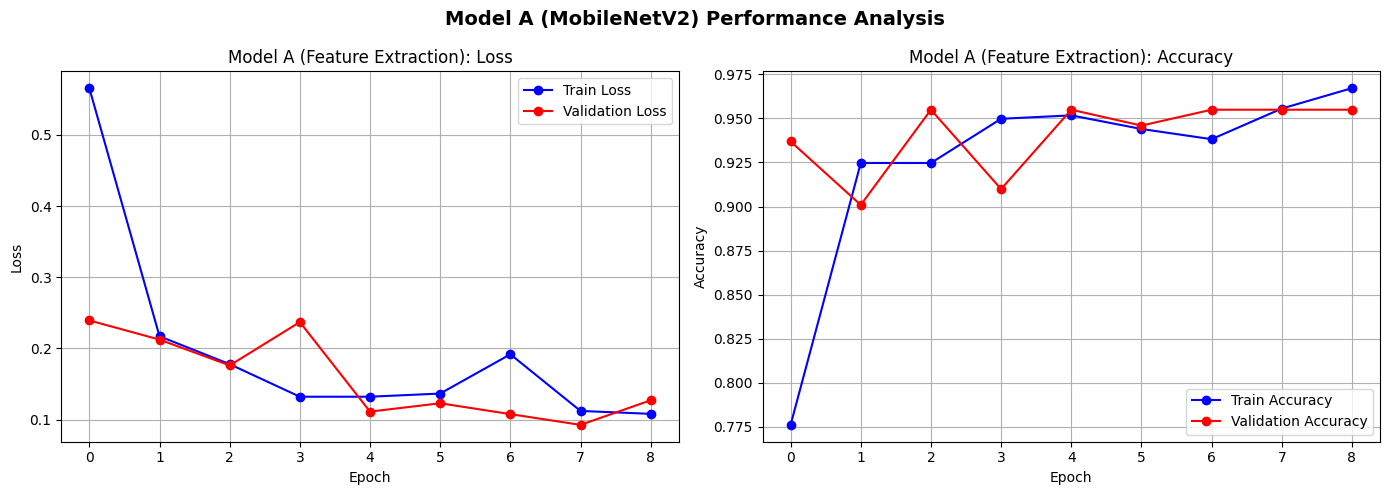

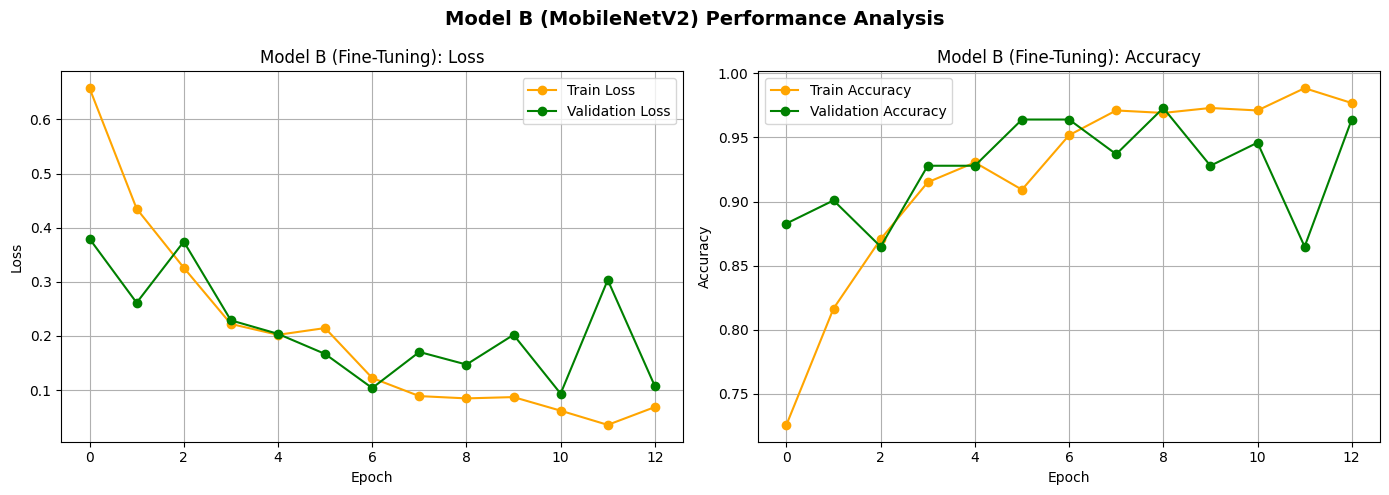


--- [MODEL SELECTION -- VALIDATION ACCURACY] ---
Model A (Feature Extraction) Best Val Accuracy: 0.9550
Model B (Fine-Tuning) Best Val Accuracy: 0.9730

[SELECTED] Model B selected for test-set evaluation (higher val accuracy).

--- [UNSEEN TEST SET EVALUATION] ---
Test Loss: 0.1394 | Test Accuracy: 0.9554

>>> FINAL REPORTED ACCURACY (use this number in the report): 95.54% <<<

--- [CLASSIFICATION REPORT] ---
              precision    recall  f1-score   support

   capacitor       0.98      0.98      0.98        48
       diode       0.88      0.97      0.92        29
    resistor       1.00      0.91      0.96        35

    accuracy                           0.96       112
   macro avg       0.95      0.95      0.95       112
weighted avg       0.96      0.96      0.96       112



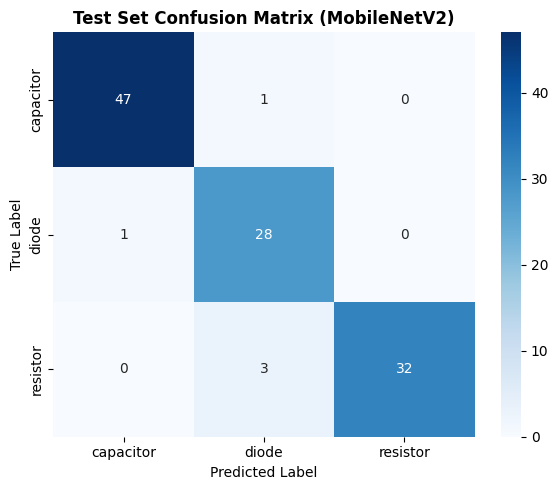

[SUCCESS] Best model weights saved as 'best_model_b_finetune_mobilenet.pth'.
[INFO] Downloading 'best_model_b_finetune_mobilenet.pth' to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
"""Cell: Direct Comparison & Plotting (Model A vs Model B) — MobileNetV2"""

import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from google.colab import files

# --- Plot Model A: Train vs Validation ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_a_mnet['train_loss'], label='Train Loss', marker='o', color='blue')
plt.plot(history_a_mnet['val_loss'], label='Validation Loss', marker='o', color='red')
plt.title('Model A (Feature Extraction): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_a_mnet['train_acc'], label='Train Accuracy', marker='o', color='blue')
plt.plot(history_a_mnet['val_acc'], label='Validation Accuracy', marker='o', color='red')
plt.title('Model A (Feature Extraction): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model A (MobileNetV2) Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot Model B: Train vs Validation ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_b_mnet['train_loss'], label='Train Loss', marker='o', color='orange')
plt.plot(history_b_mnet['val_loss'], label='Validation Loss', marker='o', color='green')
plt.title('Model B (Fine-Tuning): Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_b_mnet['train_acc'], label='Train Accuracy', marker='o', color='orange')
plt.plot(history_b_mnet['val_acc'], label='Validation Accuracy', marker='o', color='green')
plt.title('Model B (Fine-Tuning): Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model B (MobileNetV2) Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Determine the best model based on Validation Accuracy ---
# NOTE: validation accuracy is used ONLY to select which model to carry
# forward to the held-out test set. It is NOT the final reported metric --
# the test accuracy computed below is the number that belongs in the report.
max_acc_a_mnet = max(history_a_mnet['val_acc'])
max_acc_b_mnet = max(history_b_mnet['val_acc'])

print(f"\n--- [MODEL SELECTION -- VALIDATION ACCURACY] ---")
print(f"Model A (Feature Extraction) Best Val Accuracy: {max_acc_a_mnet:.4f}")
print(f"Model B (Fine-Tuning) Best Val Accuracy: {max_acc_b_mnet:.4f}")

if max_acc_b_mnet >= max_acc_a_mnet:
    best_model = model_b_mnet
    best_file = "best_model_b_finetune_mobilenet.pth"
    print(f"\n[SELECTED] Model B selected for test-set evaluation (higher val accuracy).")
else:
    best_model = model_a_mnet
    best_file = "best_model_a_fe_mobilenet.pth"
    print(f"\n[SELECTED] Model A selected for test-set evaluation (higher val accuracy).")

# --- Final Rigorous Evaluation on the Unseen Test Set ---
print(f"\n--- [UNSEEN TEST SET EVALUATION] ---")
best_model.eval()
test_loss = 0.0
test_corrects = 0
all_preds = []
all_labels = []

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_epoch_loss = test_loss / test_size
test_epoch_acc = test_corrects.double().item() / test_size

print(f"Test Loss: {test_epoch_loss:.4f} | Test Accuracy: {test_epoch_acc:.4f}")
print(f"\n>>> FINAL REPORTED ACCURACY (use this number in the report): {test_epoch_acc*100:.2f}% <<<")

# --- Generate Confusion Matrix & Classification Report ---
print("\n--- [CLASSIFICATION REPORT] ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Test Set Confusion Matrix (MobileNetV2)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Save and Download Best Model Weights ---
torch.save(best_model.state_dict(), best_file)
print(f"[SUCCESS] Best model weights saved as '{best_file}'.")
print(f"[INFO] Downloading '{best_file}' to your computer...")
files.download(best_file)

Cell 19 (Ablation) — MobileNetV2: Isolated Adam vs. SGD

In [11]:
# --- Ablation: features[14:] + classifier unfrozen, Adam (MobileNetV2) ---
model_a2_mnet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for param in model_a2_mnet.parameters():
    param.requires_grad = False

for idx, module in enumerate(model_a2_mnet.features):
    if idx >= 14:
        for param in module.parameters():
            param.requires_grad = True

model_a2_mnet.classifier = nn.Linear(model_a2_mnet.classifier[1].in_features, len(class_names))
for param in model_a2_mnet.classifier.parameters():
    param.requires_grad = True
model_a2_mnet = model_a2_mnet.to(device)

optimizer_a2_mnet = optim.Adam(
    filter(lambda p: p.requires_grad, model_a2_mnet.parameters()),
    lr=0.001, weight_decay=1e-4
)

model_a2_mnet, history_a2_mnet = train_and_evaluate(
    model_a2_mnet, train_loader, val_loader, train_size, val_size,
    optimizer_a2_mnet, criterion, device, num_epochs=15, patience=4
)

print(f"\n[ABLATION] features[14:]+classifier unfrozen, Adam -- Best Val Acc: {max(history_a2_mnet['val_acc']):.4f}")
print(f"[ABLATION] features[14:]+classifier unfrozen, SGD   -- Best Val Acc: {max_acc_b_mnet:.4f}  (this is Model B, already trained above)")
print("\nCompare these two lines directly -- same unfrozen layers, optimizer is the only difference.")

Epoch [1/15] -> Train Loss: 0.5788 | Train Acc: 0.7819 || Val Loss: 0.3162 | Val Acc: 0.9189
--> [CHECKPOINT] Best model updated with Val Acc: 0.9189
Epoch [2/15] -> Train Loss: 0.3419 | Train Acc: 0.9093 || Val Loss: 0.1990 | Val Acc: 0.9369
--> [CHECKPOINT] Best model updated with Val Acc: 0.9369
Epoch [3/15] -> Train Loss: 0.1762 | Train Acc: 0.9479 || Val Loss: 0.2462 | Val Acc: 0.9099
--> [WARNING] No improvement. Early Stopping counter: 1/4
Epoch [4/15] -> Train Loss: 0.1740 | Train Acc: 0.9498 || Val Loss: 0.1646 | Val Acc: 0.9279
--> [WARNING] No improvement. Early Stopping counter: 2/4
Epoch [5/15] -> Train Loss: 0.1033 | Train Acc: 0.9653 || Val Loss: 0.1017 | Val Acc: 0.9640
--> [CHECKPOINT] Best model updated with Val Acc: 0.9640
Epoch [6/15] -> Train Loss: 0.1588 | Train Acc: 0.9421 || Val Loss: 0.0378 | Val Acc: 0.9910
--> [CHECKPOINT] Best model updated with Val Acc: 0.9910
Epoch [7/15] -> Train Loss: 0.1647 | Train Acc: 0.9459 || Val Loss: 0.0838 | Val Acc: 0.9550
--> [

In [21]:
import pandas as pd

summary = pd.DataFrame({
    "Model": [
        "DenseNet121",
        "DenseNet121",
        "MobileNetV2",
        "MobileNetV2",
    ],
    "Experiment": [
        "Feature Extraction",
        "Fine-Tuning",
        "Feature Extraction",
        "Fine-Tuning",
    ],
    "Optimizer": [
        "Adam",
        "SGD",
        "Adam",
        "SGD",
    ],
    "Best Validation Accuracy": [
        max(history_a["val_acc"]),
        max(history_b["val_acc"]),
        max(history_a_mnet["val_acc"]),
        max(history_b_mnet["val_acc"]),
    ]
})

display(summary)

,Model,Experiment,Optimizer,Best Validation Accuracy
0,DenseNet121,Feature Extraction,Adam,0.936937
1,DenseNet121,Fine-Tuning,SGD,0.990991
2,MobileNetV2,Feature Extraction,Adam,0.954955
3,MobileNetV2,Fine-Tuning,SGD,0.972973


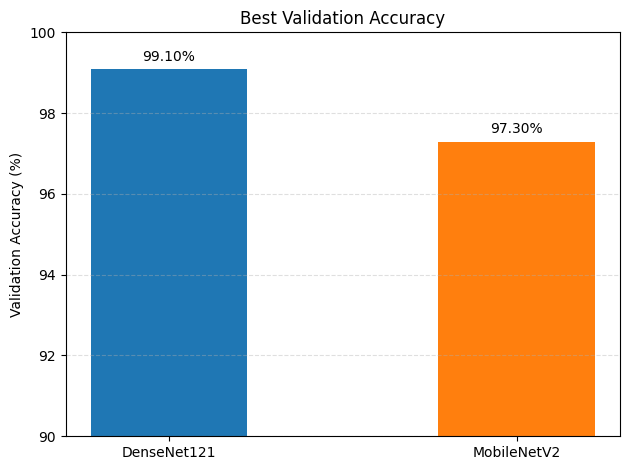

In [13]:
import matplotlib.pyplot as plt

comparison = summary[summary["Experiment"] == "Fine-Tuning"]

models = comparison["Model"]
val_acc = comparison["Best Validation Accuracy"] * 100  # إذا كانت القيم بين 0 و1

bars = plt.bar(
    models,
    val_acc,
    color=['#1f77b4', '#ff7f0e'],
    width=0.45
)

plt.title("Best Validation Accuracy")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(90, 100)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.2,
        f'{y:.2f}%',
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##Grad-CAM model (DenseNet121)

In [17]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=ed50773c3b9a9adc78a92310e4b9200c11621875bff5aae34d313d6f2789ced8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [19]:

model = model_b
model.eval()

target_layers = [model.features.norm5]
cam = GradCAM(
    model=model,
    target_layers=target_layers
)
images, labels = next(iter(test_loader))

image_tensor = images[0]
label = labels[0]

input_tensor = image_tensor.unsqueeze(0).to(device)
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, pred = torch.max(probabilities, 1)

pred = pred.item()
confidence = confidence.item()
targets = [ClassifierOutputTarget(pred)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]
image = image_tensor.cpu().permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image * std + mean
image = np.clip(image, 0, 1)
visualization = show_cam_on_image(
    image,
    grayscale_cam,
    use_rgb=True
)

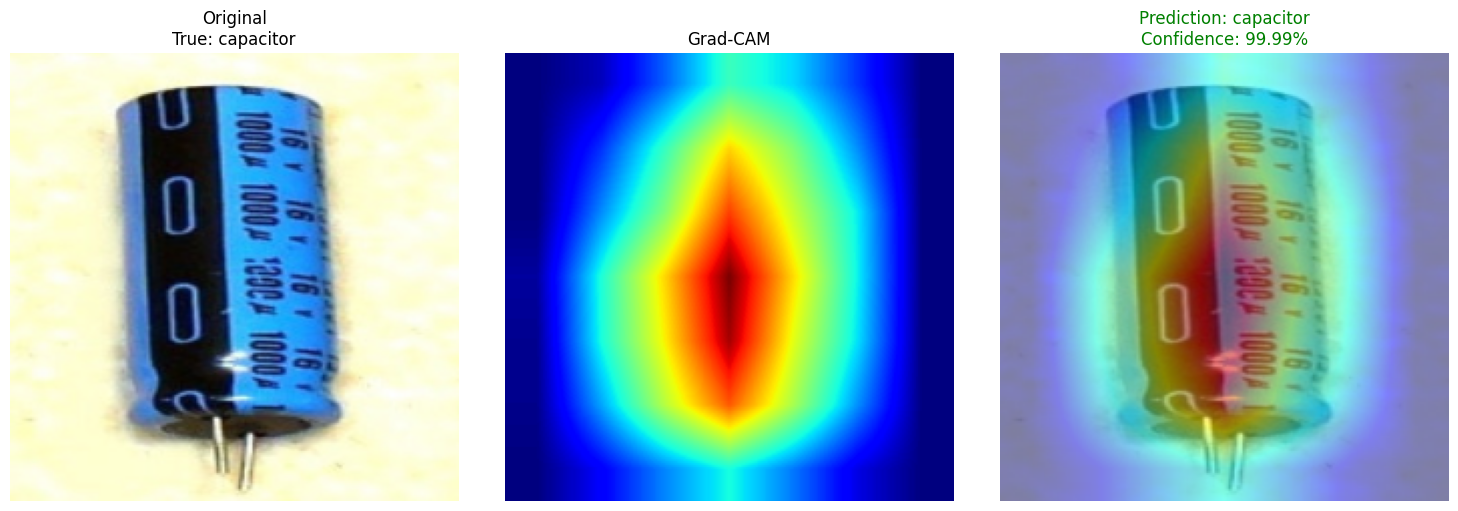

True Label      : capacitor
Predicted Label : capacitor
Confidence      : 99.99%
 Correct Prediction


In [20]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title(f"Original\nTrue: {class_names[label]}")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(visualization)

color = "green" if pred == label else "red"

plt.title(
    f"Prediction: {class_names[pred]}\n"
    f"Confidence: {confidence*100:.2f}%",
    color=color
)

plt.axis("off")

plt.tight_layout()
plt.show()

print(f"True Label      : {class_names[label]}")
print(f"Predicted Label : {class_names[pred]}")
print(f"Confidence      : {confidence*100:.2f}%")

if pred == label:
    print(" Correct Prediction")
else:
    print(" Incorrect Prediction")